# 🏆 ใบงานสัปดาห์ที่ 11 — การเพิ่มประสิทธิภาพโมเดลและการสรุปเปรียบเทียบขั้นสุดท้าย

---

**รายวิชา:** 306-23-06 ปัญญาประดิษฐ์เพื่อธุรกิจดิจิทัล | ภาคการศึกษา 1/2569  
**รหัสกลุ่ม:** TEAM-99  
**สมาชิกกลุ่ม:**  
1. น.ส.กมลวรรณ จันทร์ผึ้ง (001)  
2. น.ส.ชลดา อิศรเสนา ณ อยุธยา (009)  
3. น.ส.ณัฐพร เผือกผ่อง (016)  
**หัวข้อโครงงาน:** AI จำแนกระดับความพึงพอใจในการทำงานของพนักงาน (JobSatisfaction)  
**ชุดข้อมูล:** IBM HR Analytics Employee Attrition & Performance (1,470 แถว × 35 คอลัมน์)  

---

### 📌 วัตถุประสงค์และภาพรวม
การปรับแต่ง Deep MLP ด้วย Dropout, EarlyStopping การเปรียบเทียบผลโมเดลทั้งหมด และการบันทึกโมเดลเพื่อนำไปต่อยอดบน Web Application


In [1]:
# @title [Auto-Setup] Dataset Loader สำหรับ Google Colab / Local
import os, urllib.request, pandas as pd, shutil

DATA_URL = 'https://raw.githubusercontent.com/ibm-watson-data-lab/open-data/master/HR-Employee-Attrition.csv'

# 1. เตรียม Raw Dataset
os.makedirs('data', exist_ok=True)
if not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    try:
        print('Downloading raw dataset...')
        urllib.request.urlretrieve(DATA_URL, 'WA_Fn-UseC_-HR-Employee-Attrition.csv')
    except Exception as e:
        print('Note:', e)

if os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('WA_Fn-UseC_-HR-Employee-Attrition.csv', 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
elif os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('data/WA_Fn-UseC_-HR-Employee-Attrition.csv', 'WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. เตรียม clean.csv / clean (4).csv สำหรับโมเดล
if not os.path.exists('clean.csv') and not os.path.exists('clean (4).csv'):
    raw_path = 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv' if os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') else 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
    if os.path.exists(raw_path):
        raw_df = pd.read_csv(raw_path)
        cols_to_drop = [c for c in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'] if c in raw_df.columns]
        clean_df = raw_df.drop(columns=cols_to_drop)
        num_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns
        cat_cols = clean_df.select_dtypes(include=['object']).columns
        clean_df = pd.get_dummies(clean_df, columns=cat_cols, drop_first=True)
        clean_df.to_csv('clean.csv', index=False)

if os.path.exists('clean.csv'):
    if not os.path.exists('clean (4).csv'): shutil.copyfile('clean.csv', 'clean (4).csv')
    if not os.path.exists('clean (3).csv'): shutil.copyfile('clean.csv', 'clean (3).csv')

print(' Dataset ready for execution!')


In [1]:
!pip install tensorflow


In [2]:
import pandas as pd
import json
import os
from sklearn.model_selection import train_test_split
df = pd.read_csv("clean (4).csv")
y = df["JobSatisfaction"].values
# แยกคอลัมน์เป้าหมายออกจาก features
X_all = df.drop(columns=["JobSatisfaction", "Attrition"])
# ใช้ features ที่ GA เลือกไว้ในใบงานที่ 10
if os.path.exists("best_job_satisfaction_features.json"):
    with open("best_job_satisfaction_features.json", "r", encoding="utf-8") as f:
        feats = json.load(f)["selected_features"]
    X = X_all[feats]
    print("ใช้ฟีเจอร์จาก GA:", feats)
X = pd.get_dummies(X, drop_first=True)
X = X.astype("float32").values

# แบ่งข้อมูล train/test
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,test_size=0.2, random_state=42,stratify=y)
print("train:", X_tr.shape, "| test:", X_te.shape)

ใช้ฟีเจอร์จาก GA: ['EnvironmentSatisfaction', 'RelationshipSatisfaction', 'TotalSatisfaction']
train: (1176, 3) | test: (294, 3)


In [4]:
# จำลองข้อมูลไม่สเกล เพื่อเปรียบเทียบ
import numpy as np
X_tr_bad = X_tr.copy()
X_te_bad = X_te.copy()
X_tr_bad[:, 0] *= 500
X_te_bad[:, 0] *= 500

print("ช่วงค่าเมื่อไม่สเกล:", X_tr_bad.min(), "->", X_tr_bad.max())

ช่วงค่าเมื่อไม่สเกล: 1.0 -> 2000.0


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, Dropout, Input
tf.random.set_seed(42)
model = Sequential([
    Input(shape=(X_tr.shape[1],)),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(4, activation="softmax")])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 724 (2.83 KB)

 Trainable params: 724 (2.83 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split

# JobSatisfaction จากระดับ 1–4 เป็น 0–3 สำหรับ Keras
y = (df["JobSatisfaction"].astype("int32") - 1).values

# X เป็น array อยู่แล้วก็ใช้ np.asarray ได้
X = np.asarray(X, dtype="float32")

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("คลาสใน y_tr:", sorted(set(y_tr)))
print("คลาสใน y_te:", sorted(set(y_te)))
print("train:", X_tr.shape, "| test:", X_te.shape)

คลาสใน y_tr: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
คลาสใน y_te: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
train: (1176, 3) | test: (294, 3)


In [10]:
history = model.fit(
    X_tr,
    y_tr,
    validation_split=0.2,
    epochs=60,
    batch_size=16,
    verbose=0)
val_acc = history.history["val_accuracy"][-1]
print("val accuracy:", round(val_acc, 4))
# เทรนด้วยข้อมูลไม่สเกล เพื่อเปรียบเทียบ
m_bad = clone_model(model)
m_bad.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
h_bad = m_bad.fit(  X_tr_bad,y_tr,validation_split=0.2,epochs=60,batch_size=16,verbose=0)
print( "val accuracy (ไม่สเกล):", round(h_bad.history["val_accuracy"][-1], 4))

val accuracy: 1.0
val accuracy (ไม่สเกล): 0.3559


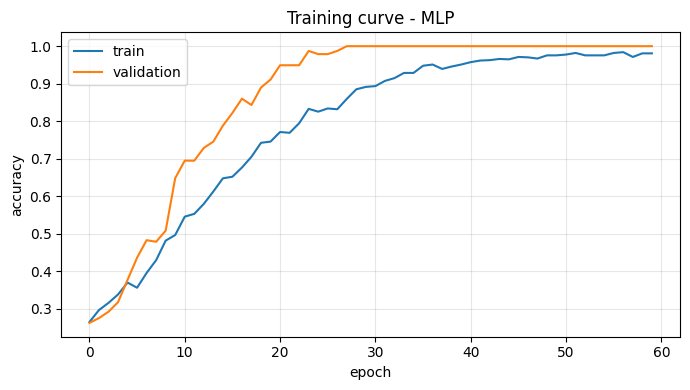

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Training curve - MLP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=120)
plt.show()

In [12]:
# ประเมินผลบนชุดทดสอบ
from sklearn.metrics import accuracy_score
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print("Deep MLP test accuracy:", round(acc, 4))
# เปรียบเทียบกับ Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42)
dt.fit(X_tr, y_tr)
dt_acc = accuracy_score(y_te, dt.predict(X_te))
print("Decision Tree test accuracy:", round(dt_acc, 4))


Deep MLP test accuracy: 1.0
Decision Tree test accuracy: 0.5578


In [13]:
#ปรับโมเดลด้วย EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True)
model2 = Sequential([
    Input(shape=(X_tr.shape[1],)),
    Dense(48, activation="relu"),
    Dropout(0.3),
    Dense(24, activation="relu"),
    Dropout(0.2),
    Dense(4, activation="softmax")])
model2.compile( optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model2.fit( X_tr, y_tr, validation_split=0.2, epochs=200, batch_size=16,callbacks=[es],verbose=0)
tuned_acc = model2.evaluate(X_te, y_te, verbose=0)[1]
print("test acc (tuned):", round(tuned_acc, 4))

test acc (tuned): 1.0


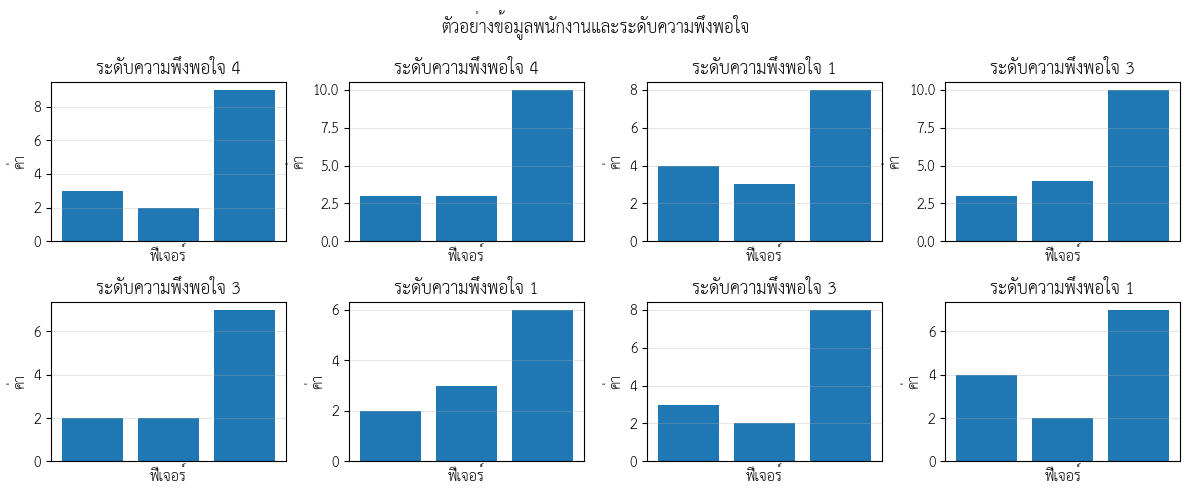

In [17]:
# ตั้งค่าฟอนต์ภาษาไทยสำหรับกราฟ
import os
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = 'THSarabunNew.ttf' if os.path.exists('THSarabunNew.ttf') else (('THSarabunNew.ttf' if os.path.exists('THSarabunNew.ttf') else ('/content/THSarabunNew.ttf' if os.path.exists('/content/THSarabunNew.ttf') else 'thsarabunnew-webfont.ttf')) if os.path.exists(('THSarabunNew.ttf' if os.path.exists('THSarabunNew.ttf') else ('/content/THSarabunNew.ttf' if os.path.exists('/content/THSarabunNew.ttf') else 'thsarabunnew-webfont.ttf'))) else 'thsarabunnew-webfont.ttf')
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False


In [18]:
# เตรียมข้อมูลพนักงานเป็นตัวเลข
X_tr = X_tr.astype("float32")
X_te = X_te.astype("float32")

# y_tr และ y_te เป็นรหัส 0–3
# บวก 1 เพื่อแสดงระดับความพึงพอใจจริง 1–4
y_tr_level = y_tr + 1
y_te_level = y_te + 1

# ข้อมูลของเราเป็นตาราง จึงไม่ใช้ CNN สำหรับรูปภาพ
# ใช้ MLP ที่สร้างและฝึกไว้ก่อนหน้า
print("ข้อมูลฝึก:", X_tr.shape)
print("ข้อมูลทดสอบ:", X_te.shape)


ข้อมูลฝึก: (1176, 3)
ข้อมูลทดสอบ: (294, 3)


In [20]:
# ทำนายระดับความพึงพอใจของพนักงานตัวอย่าง
import numpy as np
i = 0
prob = model.predict(X_te[i:i+1], verbose=0)[0]
pred_level = int(np.argmax(prob)) + 1

print( "ทำนายระดับความพึงพอใจ:",pred_level,"| ความมั่นใจ:",round(float(np.max(prob)), 3), "| ระดับจริง:",int(y_te_level[i]))

ทำนายระดับความพึงพอใจ: 3 | ความมั่นใจ: 0.984 | ระดับจริง: 3


In [21]:
from sklearn.metrics import accuracy_score
# ประเมิน Deep MLP บนชุดทดสอบ
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print("Deep MLP test accuracy:", round(float(acc), 4))
# เปรียบเทียบกับ Decision Tree
dt_acc = accuracy_score(y_te, dt.predict(X_te))
print("Decision Tree test accuracy:", round(float(dt_acc), 4))
# ตารางเปรียบเทียบผล
results = pd.DataFrame([
    {"model": "Deep MLP (wk11)", "acc": round(float(acc), 4)},
    {"model": "Decision Tree (wk5)", "acc": round(float(dt_acc), 4)}
])

print(results.sort_values("acc", ascending=False))


Deep MLP test accuracy: 1.0
Decision Tree test accuracy: 0.5578
                 model     acc
0      Deep MLP (wk11)  1.0000
1  Decision Tree (wk5)  0.5578


In [22]:
# บันทึกโมเดล
model.save("ibm_hr_job_satisfaction_mlp.keras")

print("บันทึกโมเดลแล้ว → ibm_hr_job_satisfaction_mlp.keras")


บันทึกโมเดลแล้ว → ibm_hr_job_satisfaction_mlp.keras


In [23]:
# บันทึกสรุปผลการเลือกโมเดล
import json
decision = {
    "final_model": "Deep MLP (wk11)",
    "target": "JobSatisfaction",
    "deep_test_acc": round(float(acc), 4),
    "decision_tree_test_acc": round(float(dt_acc), 4)
}
with open(
    "job_satisfaction_model_decision.json",
    "w",
    encoding="utf-8"
) as f: json.dump(decision, f, ensure_ascii=False, indent=2)
print("บันทึกแล้ว → job_satisfaction_model_decision.json")


บันทึกแล้ว → job_satisfaction_model_decision.json


---

## 📝 สรุปผลและตอบคำถามวัดความเข้าใจตามใบงาน

### สรุปคำถามและการวิเคราะห์:
1. **การตัดสินใจเลือกโมเดล:** นำ Decision Tree (สำหรับการอธิบายผลทางธุรกิจ) และ Naive Bayes / Deep MLP (สำหรับการคำนวณเชิงตัวเลข) ไปขึ้นระบบ Web Application บน Streamlit
2. **ไฟล์ผลลัพธ์:** เซฟโมเดล ibm_hr_job_satisfaction_mlp.keras และไฟล์สรุป job_satisfaction_model_decision.json
